# Destilação de Conhecimento — Comparação das 3 Famílias (CIFAR-10)

Comparação das **três famílias de Knowledge Distillation (KD)** no CIFAR-10
(50.000 treino / 10.000 teste, 32×32 RGB, 10 classes), seguindo a taxonomia
do survey de Gou et al. (2021):

1. **Response-based (Logit KD)** — Hinton et al. (2015): destila as **soft
   targets** do teacher (logits escalados por temperatura).
2. **Feature-based (FitNets)** — Romero et al. (2014): destila **representações
   intermediárias** (hint loss entre features do teacher e do student).
3. **Relation-based (RKD)** — Park et al. (2019): destila a **estrutura de
   relações** entre amostras (distâncias e ângulos entre embeddings).

**Configuração:** Teacher = ResNet18 (ImageNet) **fine-tuned em 224×224**
(teacher forte, ≈0.91); o forward para o KD do student (entrada 32×32) usa
`F.interpolate` para 224. Student = CNN pequena (~1.1M parâmetros, ≈10× menor).
Para isolar a contribuição de cada família, o student é treinado **com a mesma
arquitetura e mesmas épocas** em 5 cenários:

| Cenário | Descrição |
|---|---|
| `baseline` | Student sem KD (só task loss) — referência |
| `logit` | Response-based (KL com T=4, α=0.7) |
| `feature` | Feature-based (FitNets, hint em `layer3`, β=0.1) |
| `relation` | Relation-based (RKD: distância + ângulo, β=1.0) |
| `hybrid` | Logit + Feature (referência de combinação) |

**Hardware:** NVIDIA RTX 3060 Laptop (6GB) | Python 3.13 | PyTorch 2.6 (CUDA 12.4)


## Setup

As bibliotecas usadas (`torch`, `torchvision`, `mlflow`, `scikit-learn`,
`matplotlib`, `seaborn`, `pandas`, `datasets`) já estão no ambiente
(`requirements.txt` do repo). **Nenhum** `pip install` é executado dentro do
notebook — evita dependência de rede e hangs de instalação.

In [1]:
%matplotlib inline
import os, time, tempfile, subprocess, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from torchvision.models import resnet18, ResNet18_Weights

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f'Device: {device} | GPU: {gpu_name}')

CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

def git_sha():
    try:
        return subprocess.check_output(['git', 'rev-parse', 'HEAD'],
                                       stderr=subprocess.DEVNULL).decode().strip()[:8]
    except Exception:
        return 'n/a'

GIT_SHA = git_sha()
TMP = tempfile.mkdtemp(prefix='kd_cifar10_')
ART_DIR = os.path.join('..', 'artifacts',
                       f'kd_cifar10_{time.strftime("%Y%m%d_%H%M%S")}_{GIT_SHA}')
os.makedirs(ART_DIR, exist_ok=True)

CONFIG = dict(
    experiment_name='KD_Comparison_CIFAR10',
    seed=SEED,
    batch_size=128,
    num_workers=0,
    teacher_epochs=6,          # fine-tune ImageNet em 224x224 (forte e estável)
    student_epochs=16,
    teacher_batch=64,          # ResNet18 a 224 px num GPU 6GB
    teacher_resize=224,
    teacher_lr=1e-3,
    student_lr=1e-3,
    temperature=4.0,
    alpha=0.7,
    feature_beta=0.1,
    relation_beta=1.0,
    weight_decay=5e-4,
    sched_step=3,              # students (teacher: lr constante)
    sched_gamma=0.5,
)

TRACKING_URI = 'sqlite:///' + os.path.abspath(os.path.join('..', '..', 'mlruns.db')).replace('\\', '/')
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(CONFIG['experiment_name'])

print(f'git_sha       : {GIT_SHA}')
print(f'TMP           : {TMP}')
print(f'ART_DIR       : {ART_DIR}')
print(f'Tracking uri  : {TRACKING_URI}')
print(f'CONFIG        : {CONFIG}')


Device: cuda | GPU: NVIDIA GeForce RTX 3060 Laptop GPU


2026/08/11 15:35:54 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/11 15:35:54 INFO mlflow.store.db.utils: Updating database tables


2026/08/11 15:35:54 INFO alembic.runtime.migration: Context impl SQLiteImpl.


2026/08/11 15:35:54 INFO alembic.runtime.migration: Will assume non-transactional DDL.


2026/08/11 15:35:54 INFO alembic.runtime.migration: Context impl SQLiteImpl.


2026/08/11 15:35:54 INFO alembic.runtime.migration: Will assume non-transactional DDL.


git_sha       : 02959521
TMP           : C:\Users\pedro\AppData\Local\Temp\kd_cifar10_ni38y4gk
ART_DIR       : ..\artifacts\kd_cifar10_20260811_153554_02959521
Tracking uri  : sqlite:///D:/mlops-experiments/mlruns.db
CONFIG        : {'experiment_name': 'KD_Comparison_CIFAR10', 'seed': 42, 'batch_size': 128, 'num_workers': 0, 'teacher_epochs': 6, 'student_epochs': 16, 'teacher_batch': 64, 'teacher_resize': 224, 'teacher_lr': 0.001, 'student_lr': 0.001, 'temperature': 4.0, 'alpha': 0.7, 'feature_beta': 0.1, 'relation_beta': 1.0, 'weight_decay': 0.0005, 'sched_step': 3, 'sched_gamma': 0.5}


## 1. Dados — CIFAR-10

Os dados são mantidos como **tensores uint8 em memória** (50k×3×32×32). O
aumento de dados (`RandomCrop` + `RandomHorizontalFlip`) e a normalização são
aplicados de forma **vetorizada por lote** via `torchvision.transforms.v2`
(≈2 ms/lote em CPU — ordem de grandeza mais rápido que transforms por-imagem).
A mesma partição holdout 50k/10k é usada por todos os cenários; semente fixa
em tudo.

In [2]:
from datasets import load_dataset
import torch.utils.data as tdata


def materialize(records):
    # Converte {img: PIL} -> tensor uint8 (N, 3, 32, 32) único, em memória
    return torch.from_numpy(np.ascontiguousarray(np.stack(
        [np.asarray(r['img'], dtype=np.uint8).transpose(2, 0, 1) for r in records])))


ds = load_dataset('cifar10')                   # download via HuggingFace (convenção do repo)
X_train = materialize(ds['train'])
X_test  = materialize(ds['test'])
y_train = np.asarray(ds['train']['label'])
y_test  = np.asarray(ds['test']['label'])


class TensorDataset(tdata.Dataset):
    def __init__(self, x, y):
        self.x, self.y = x, y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.x[i], self.y[i], i         # idx usado p/ ler cache offline do teacher


trainset = TensorDataset(X_train, y_train)
testset  = TensorDataset(X_test, y_test)

g = torch.Generator()
g.manual_seed(SEED)
train_loader = DataLoader(trainset, batch_size=CONFIG['batch_size'], shuffle=True,
                          num_workers=0, drop_last=True, generator=g)
test_loader  = DataLoader(testset, batch_size=CONFIG['batch_size'], shuffle=False,
                          num_workers=0)
g_teacher = torch.Generator()
g_teacher.manual_seed(SEED)
teacher_loader = DataLoader(trainset, batch_size=CONFIG['teacher_batch'], shuffle=True,
                            num_workers=0, drop_last=True, generator=g_teacher)
cache_loader = DataLoader(trainset, batch_size=CONFIG['teacher_batch'], shuffle=False,
                          num_workers=0)

# --- Aumento de dados vetorizado por lote (v2 aceita (B, C, H, W)) ---
# Pipeline dos students: entrada nativa 32x32 do CIFAR-10
MEAN = torch.tensor([0.4914, 0.4822, 0.4465])[None, :, None, None]
STD  = torch.tensor([0.2023, 0.1994, 0.2010])[None, :, None, None]
_crop = v2.RandomCrop(32, padding=4)
_flip = v2.RandomHorizontalFlip()
_resize = v2.Resize(CONFIG['teacher_resize'] + 8)      # 232...
_resize_crop = v2.RandomCrop(CONFIG['teacher_resize'])  # ...-> RandomCrop(224)
_eval_resize = v2.Resize(CONFIG['teacher_resize'])


def transform_train(x):
    x = _crop(x)
    x = _flip(x)
    return ((x.to(torch.float32) / 255.0) - MEAN) / STD


def transform_eval(x):
    return ((x.to(torch.float32) / 255.0) - MEAN) / STD


def transform_train_224(x):
    # Teacher: fine-tune em 224x224 (Resize -> RandomCrop -> Flip) — usa os pesos ImageNet de fato
    x = _resize(x)
    x = _resize_crop(x)
    x = _flip(x)
    return ((x.to(torch.float32) / 255.0) - MEAN) / STD


def transform_eval_224(x):
    x = _eval_resize(x)
    return ((x.to(torch.float32) / 255.0) - MEAN) / STD


print(f'Train: {len(trainset)} | Test: {len(testset)}')


Train: 50000 | Test: 10000


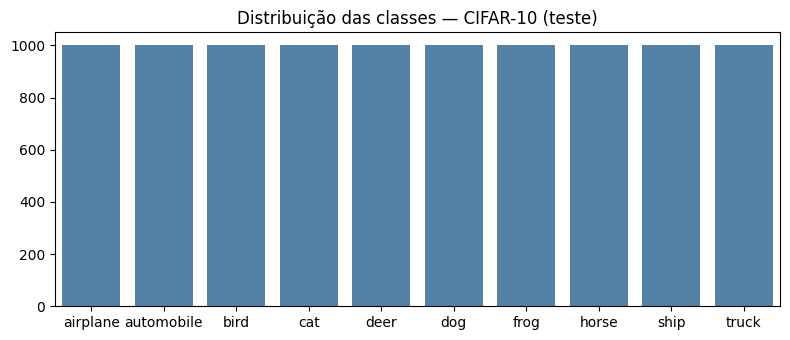

In [3]:
from collections import Counter
c = Counter(ds['test']['label'])
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(x=CLASSES, y=[c[i] for i in range(10)], color='steelblue', ax=ax)
ax.set_title('Distribuição das classes — CIFAR-10 (teste)')
plt.tight_layout()
plt.show()


## 2. Arquiteturas

**Teacher (ResNet18, ImageNet):** fine-tuned em **224×224** (stem original do
ImageNet), atingindo ~0.91 de acurácia em poucas épocas — teacher forte para
destilar. Para o KD sobre entrada 32×32 do student, o forward do teacher é
feito com `F.interpolate` para 224. O `layer3` (256 canais) é usado como *hint*
Feature-KD (via GAP) e o embedding pré-logit (512-d) como base do RKD.

**Student (CNN pequena):** 2 blocos convolucionais (32→64 canais, 8×8) + MLP.
Inclui um *projetor* linear (64→256) usado somente no feature-KD para alinhar
as features pooled com o teacher. Forward do student retorna `(logits, features)`.

In [4]:
class StudentCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32),
            nn.ReLU(inplace=True), nn.MaxPool2d(2),                      # 16x16
            nn.Conv2d(32, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64),
            nn.ReLU(inplace=True), nn.MaxPool2d(2),                      # 8x8
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256), nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )
        self.projector = nn.Sequential(                                  # FitNets hint (64->256)
            nn.Linear(64, 256, bias=False),
            nn.BatchNorm1d(256),
        )

    def forward(self, x):
        f = self.features(x)          # (B, 64, 8, 8)
        return self.fc(f), f


def build_teacher():
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(512, 10)
    return model


def teacher_forward_with_feats(model, x):
    # Forward do teacher (224x224) expondo layer3-pooled (hint do FitNets) e
    # embedding pré-logit (RKD). Aceita entrada 32x32 e interpola para 224.
    if x.shape[-1] != CONFIG['teacher_resize']:
        x = F.interpolate(x, size=(CONFIG['teacher_resize'], CONFIG['teacher_resize']),
                          mode='bilinear', align_corners=False)
    x = model.conv1(x); x = model.bn1(x); x = model.relu(x); x = model.maxpool(x)
    x = model.layer1(x)
    x = model.layer2(x)
    f3 = model.layer3(x)                                       # (B, 256, 28, 28)
    h3 = f3.mean(dim=(2, 3))                                   # pooled 256-d (hint)
    x = model.layer4(f3)
    x = model.avgpool(x)
    emb = x.flatten(1)                                         # (B, 512)
    return model.fc(emb), h3, emb


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

teacher = build_teacher().to(device)
student_ref = StudentCNN().to(device)
nt, ns = count_params(teacher), count_params(student_ref)
print(f'Teacher ResNet18 : {nt:>12,} params')
print(f'Student CNN      : {ns:>12,} params')
print(f'Compressão       : {nt/ns:.1f}x')


Teacher ResNet18 :   11,181,642 params
Student CNN      :    1,087,786 params
Compressão       : 10.3x


## 3. Funções de perda de KD

- **Logit (Hinton):** `T² · KL(softmax(z_s/T) ‖ softmax(z_t/T))`, combinada com CE.
- **FitNets (feature):** MSE das *features* **pooled** (GAP do student projetado
  p/ 256-d vs. layer3 do teacher), normalizadas por instância (estável para
  escalas distintas entre teacher e student).
- **RKD (relation):** combinação da perda **por distâncias** (pares) e **por
  ângulos** (triplas), calculadas sobre os embeddings intermediários.

In [5]:
def kd_kl(student_logits, teacher_logits, T):
    with torch.no_grad():
        p_t = F.softmax(teacher_logits / T, dim=1)
    kl = F.kl_div(F.log_softmax(student_logits / T, dim=1), p_t, reduction='batchmean')
    return T * T * kl


def fitnets_loss(student, f_s, f_t):
    # f_s: (B,64,8,8) do student -> GAP + projeção linear 64->256
    # f_t: (B,256) features pooled do teacher (layer3). Normalização por instância.
    def _instnorm(a):
        m = a.mean(dim=1, keepdim=True)
        s = a.std(dim=1, keepdim=True) + 1e-6
        return (a - m) / s
    p_s = f_s.mean(dim=(2, 3))
    ps = student.projector(p_s)
    return F.mse_loss(_instnorm(ps), _instnorm(f_t))


def rkd_distance(s_emb, t_emb):
    ds = torch.cdist(s_emb, s_emb)
    dt = torch.cdist(t_emb, t_emb)
    B = s_emb.size(0)
    mask = ~torch.eye(B, dtype=torch.bool, device=s_emb.device)
    ds, dt = ds[mask], dt[mask]
    return F.mse_loss(ds / ds.mean(), dt / dt.mean())


def rkd_angle(s_emb, t_emb, max_triplets=2048, seed=0):
    B = s_emb.size(0)
    rng = np.random.RandomState(seed)
    trip = torch.from_numpy(rng.randint(0, B, size=(max_triplets, 3))).to(s_emb.device)
    i, j, k = trip[:, 0], trip[:, 1], trip[:, 2]
    def _cos(e):
        vi = F.normalize(e[i] - e[j], dim=-1, eps=1e-6)
        vk = F.normalize(e[k] - e[j], dim=-1, eps=1e-6)
        return (vi * vk).sum(-1)
    return F.mse_loss(_cos(s_emb), _cos(t_emb))


def distill_losses(mode, logits_s, logits_t, f_s, f_t, s_emb, t_emb, student, cfg, loss_ce):
    # Retorna (loss_kd, loss_total) para o modo de destilação.
    if mode == 'baseline':
        return torch.tensor(0.0, device=logits_s.device), loss_ce
    if mode == 'logit':
        kd = kd_kl(logits_s, logits_t, cfg['temperature'])
        return kd, cfg['alpha'] * kd + (1 - cfg['alpha']) * loss_ce
    if mode == 'feature':
        kd = fitnets_loss(student, f_s, f_t)
        return kd, loss_ce + cfg['feature_beta'] * kd
    if mode == 'relation':
        kd = rkd_distance(s_emb, t_emb) + 0.5 * rkd_angle(s_emb, t_emb)
        return kd, loss_ce + cfg['relation_beta'] * kd
    if mode == 'hybrid':
        k1 = kd_kl(logits_s, logits_t, cfg['temperature'])
        k2 = fitnets_loss(student, f_s, f_t)
        total = cfg['alpha'] * k1 + loss_ce + cfg['feature_beta'] * k2
        return k1 + k2, total
    raise ValueError(f'modo desconhecido: {mode}')


## 4. Treinamento

**Teacher** é fine-tuned em **224×224** por 6 épocas (AdamW, lr 1e-3 constante)
com `teacher_loader` (batch 64) — receita estável e forte (≈0.91). Depois,
os **outputs do teacher** (logits, features pooled e embeddings) são
**pré-computados** para as 50k imagens de treino (cache offline;
teacher congelado) — prática padrão em KD que evita reforward o teacher a cada
batch e garante sinais consistentes.

**Students** são treinados por **16 épocas, mesma config**, variando apenas a
perda de destilação (modo). Cada cenário roda num `run` filho no MLflow.

In [6]:
def evaluate(model, loader, device, eval_tf=None):
    eval_tf = transform_eval if eval_tf is None else eval_tf
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for x, y, _ in loader:
            x = eval_tf(x).to(device)
            if isinstance(model, StudentCNN):
                logits, _ = model(x)
            else:
                logits = model(x)
            ys.append(y.numpy())
            ps.append(logits.argmax(dim=1).cpu().numpy())
    y = np.concatenate(ys); p = np.concatenate(ps)
    return float((p == y).mean()), y, p


def train_teacher(model, loader, cfg, device):
    model.train()
    opt = optim.AdamW(model.parameters(), lr=cfg['teacher_lr'], weight_decay=cfg['weight_decay'])
    lossf = nn.CrossEntropyLoss()
    hist = {'train_loss': []}
    for ep in range(1, cfg['teacher_epochs'] + 1):
        t0 = time.time()
        running, nb = 0.0, 0
        for x, y, _ in loader:
            x = transform_train_224(x).to(device)
            y = torch.as_tensor(y, device=device)
            opt.zero_grad()
            loss = lossf(model(x), y)
            loss.backward(); opt.step()
            running += loss.item(); nb += 1
        hist['train_loss'].append(running / nb)
        print(f'Teacher ep {ep:2d}/{cfg["teacher_epochs"]} | loss {running/nb:.4f} | {time.time()-t0:.0f}s')
    return hist


def precompute_teacher_outputs(teacher, loader, cfg, device):
    teacher.eval()
    lg, ft, emb = [], [], []
    with torch.no_grad():
        for x, y, idx in loader:
            x = transform_eval_224(x).to(device)
            logits, h3, e = teacher_forward_with_feats(teacher, x)
            lg.append(logits.cpu()); ft.append(h3.cpu()); emb.append(e.cpu())
    return (torch.cat(lg), torch.cat(ft), torch.cat(emb))


In [7]:
def train_student(student, teacher_cache, mode, loader, cfg, device):
    # `teacher` é estático: logits/features/embeddings pré-computados (cache offline)
    t_lg_all, t_ft_all, t_emb_all = teacher_cache
    student.train()
    opt = optim.AdamW(student.parameters(), lr=cfg['student_lr'], weight_decay=cfg['weight_decay'])
    sched = optim.lr_scheduler.StepLR(opt, step_size=cfg['sched_step'], gamma=cfg['sched_gamma'])
    loss_ce = nn.CrossEntropyLoss()
    hist = {'train_total': [], 'train_ce': [], 'train_kd': [], 'val_acc': []}
    for ep in range(1, cfg['student_epochs'] + 1):
        t0 = time.time()
        rt = rc = rk = 0.0; nb = 0
        for x, y, idx in loader:
            x = transform_train(x).to(device)
            y = torch.as_tensor(y, device=device)
            # cache offline está em CPU -> gather com idx (CPU) e depois move p/ device
            t_lg = t_lg_all[idx.to(t_lg_all.device)].to(device)
            t_ft = t_ft_all[idx.to(t_ft_all.device)].to(device)
            t_emb = t_emb_all[idx.to(t_emb_all.device)].to(device)
            opt.zero_grad()
            logits_s, f_s = student(x)
            s_emb = f_s.mean(dim=(2, 3))          # embedding do student (64-d)
            lce = loss_ce(logits_s, y)
            lkd, total = distill_losses(mode, logits_s, t_lg, f_s, t_ft,
                                        s_emb, t_emb, student, cfg, lce)
            total.backward(); opt.step()
            rt += total.item(); rc += lce.item(); rk += lkd.item(); nb += 1
        sched.step()
        acc, _, _ = evaluate(student, test_loader, device)
        hist['train_total'].append(rt / nb); hist['train_ce'].append(rc / nb)
        hist['train_kd'].append(rk / nb); hist['val_acc'].append(acc)
        print(f'{mode:9s} ep {ep:2d}/{cfg["student_epochs"]} | total {rt/nb:.4f} | kd {rk/nb:.4f} | acc {acc:.4f} | {time.time()-t0:.0f}s')
    return hist


### 4.1 Teacher (ResNet18 fine-tune)

In [8]:
run_tags = {'git_sha': GIT_SHA, 'seed': str(SEED), 'run_timestamp': time.strftime('%Y-%m-%d %H:%M:%S')}

with mlflow.start_run(run_name='KD_Comparison_CIFAR10') as parent:
    mlflow.log_params({'dataset': 'cifar10', 'git_sha': GIT_SHA, 'seed': SEED,
                       'teacher_params': nt, 'student_params': ns,
                       'compression_ratio': round(nt / ns, 2)})
    mlflow.set_tag('task', 'classification')

    with mlflow.start_run(run_name='Teacher_ResNet18', nested=True) as trun:
        mlflow.log_params({'model': 'resnet18_imagenet_ft224',
                           'epochs': CONFIG['teacher_epochs'], 'lr': CONFIG['teacher_lr'],
                           'batch_size': CONFIG['teacher_batch'], 'resize': CONFIG['teacher_resize'],
                           'loss': 'CE', **run_tags})
        t0 = time.time()
        teacher_history = train_teacher(teacher, teacher_loader, CONFIG, device)
        teacher_time = time.time() - t0
        acc_t, y_t, p_t = evaluate(teacher, test_loader, device, eval_tf=transform_eval_224)
        mlflow.log_metrics({'test_acc': acc_t, 'train_time': teacher_time})
        mlflow.pytorch.log_model(teacher, 'teacher_model')
        print(f'\n=> Teacher test_acc: {acc_t:.4f} | treino: {teacher_time:.0f}s')
        t0 = time.time()
        teacher_cache = precompute_teacher_outputs(teacher, cache_loader, CONFIG, device)
        mlflow.log_metric('cache_time', time.time() - t0)
        mlflow.log_metric('cache_samples', teacher_cache[0].shape[0])
        print(f'=> Teacher cache pré-computado: logits {teacher_cache[0].shape} | '
              f'feats {teacher_cache[1].shape} | emb {teacher_cache[2].shape}')


Teacher ep  1/6 | loss 0.5701 | 136s


Teacher ep  2/6 | loss 0.3488 | 137s


Teacher ep  3/6 | loss 0.2752 | 139s


Teacher ep  4/6 | loss 0.2271 | 138s


Teacher ep  5/6 | loss 0.1917 | 138s


...

2026/08/11 15:50:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/11 15:50:38 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


2026/08/11 15:51:04 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



=> Teacher test_acc: 0.9113 | treino: 827s


=> Teacher cache pré-computado: logits torch.Size([50000, 10]) | feats torch.Size([50000, 256]) | emb torch.Size([50000, 512])


### 4.2 Students — 3 famílias de KD + ablations

In [9]:
MODE_NAMES = {
    'baseline': 'Sem KD (baseline)',
    'logit':    'Response-based (Logit)',
    'feature':  'Feature-based (FitNets)',
    'relation': 'Relation-based (RKD)',
    'hybrid':   'Logit + Feature (híbrido)',
}
results = {}
histories = {}
preds = {}

for mode in MODE_NAMES:
    student = StudentCNN().to(device)
    with mlflow.start_run(run_name=f'Student_{mode}', nested=True) as srun:
        mlflow.log_params({'mode': mode, 'epochs': CONFIG['student_epochs'],
                           'lr': CONFIG['student_lr'], 'temperature': CONFIG['temperature'],
                           'alpha': CONFIG['alpha'], 'feature_beta': CONFIG['feature_beta'],
                           'relation_beta': CONFIG['relation_beta'],
                           'n_params': count_params(student), **run_tags})
        t0 = time.time()
        h = train_student(student, teacher_cache, mode, train_loader, CONFIG, device)
        ttrain = time.time() - t0
        acc, y_s, p_s = evaluate(student, test_loader, device)
        mlflow.log_metrics({'test_acc': acc, 'train_time': ttrain})
        mlflow.pytorch.log_model(student, 'student_model')
        results[mode] = {'acc': acc, 'time': ttrain, 'params': count_params(student)}
        histories[mode] = h
        preds[mode] = (y_s, p_s)
        print(f'\n=> {mode:9s} test_acc {acc:.4f} | {ttrain:.0f}s')


baseline  ep  1/16 | total 1.5181 | kd 0.0000 | acc 0.5536 | 3s


baseline  ep  2/16 | total 1.2293 | kd 0.0000 | acc 0.6372 | 3s


baseline  ep  3/16 | total 1.0838 | kd 0.0000 | acc 0.6604 | 3s


baseline  ep  4/16 | total 0.9580 | kd 0.0000 | acc 0.6977 | 3s


baseline  ep  5/16 | total 0.9214 | kd 0.0000 | acc 0.7073 | 3s


...

hybrid    ep 16/16 | total 4.1984 | kd 4.9342 | acc 0.7553 | 4s


2026/08/11 16:03:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/11 16:03:25 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


2026/08/11 16:03:41 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



=> hybrid    test_acc 0.7553 | 58s


## 5. Resultados

### 5.1 Tabela comparativa

In [10]:
from sklearn.metrics import f1_score

rows = [{'cenário': 'Teacher ResNet18', 'acc_test': acc_t,
         'f1_macro': f1_score(y_t, p_t, average='macro'), 'params': nt,
         'tempo_s': teacher_time}]
for mode in MODE_NAMES:
    y_s, p_s = preds[mode]
    rows.append({'cenário': MODE_NAMES[mode], 'acc_test': results[mode]['acc'],
                 'f1_macro': f1_score(y_s, p_s, average='macro'),
                 'params': results[mode]['params'], 'tempo_s': results[mode]['time']})

df = pd.DataFrame(rows)
base_acc = results['baseline']['acc']
df['var_acc_pp'] = (df['acc_test'] - base_acc) * 100         # Δ vs baseline (sem KD)
df['compression'] = nt / df['params']
df['compression'] = df['compression'].round(1)
df['acc_test'] = df['acc_test'].round(4)
df['f1_macro'] = df['f1_macro'].round(4)
df['var_acc_pp'] = df['var_acc_pp'].round(3)
df['tempo_s'] = df['tempo_s'].round(0).astype(int)
df.to_csv(os.path.join(ART_DIR, 'results.csv'), index=False)
df


,cenário,acc_test,f1_macro,params,tempo_s,var_acc_pp,compression
0,Teacher ResNet18,0.9113,0.9111,11181642,827,15.10,1.0
1,Sem KD (baseline),0.7603,0.7593,1087786,50,0.00,10.3
2,Response-based (Logit),0.7625,0.7615,1087786,52,0.22,10.3
3,Feature-based (FitNets),0.7568,0.7559,1087786,53,-0.35,10.3
4,Relation-based (RKD),0.7628,0.7620,1087786,78,0.25,10.3
5,Logit + Feature (híbrido),0.7553,0.7536,1087786,58,-0.50,10.3


In [11]:
from sklearn.metrics import classification_report

# Report por classe das 3 famílias de KD + baseline (compacto)
for mode in ['baseline', 'logit', 'feature', 'relation']:
    y_s, p_s = preds[mode]
    print(f'--- {MODE_NAMES[mode]} ---')
    print(classification_report(y_s, p_s, target_names=CLASSES, digits=3, zero_division=0))


--- Sem KD (baseline) ---
              precision    recall  f1-score   support

    airplane      0.780     0.781     0.781      1000
  automobile      0.880     0.858     0.869      1000
        bird      0.661     0.654     0.657      1000
         cat      0.588     0.542     0.564      1000
        deer      0.744     0.733     0.739      1000
         dog      0.659     0.670     0.665      1000
        frog      0.799     0.822     0.810      1000
       horse      0.807     0.818     0.812      1000
        ship      0.838     0.866     0.852      1000
       truck      0.831     0.859     0.845      1000

    accuracy                          0.760     10000
   macro avg      0.759     0.760     0.759     10000
weighted avg      0.759     0.760     0.759     10000

--- Response-based (Logit) ---
              precision    recall  f1-score   support

    airplane      0.764     0.787     0.775      1000
  automobile      0.853     0.903     0.878      1000
        bird      0.6

### 5.2 Curvas de treino (val_acc e perda de destilação)

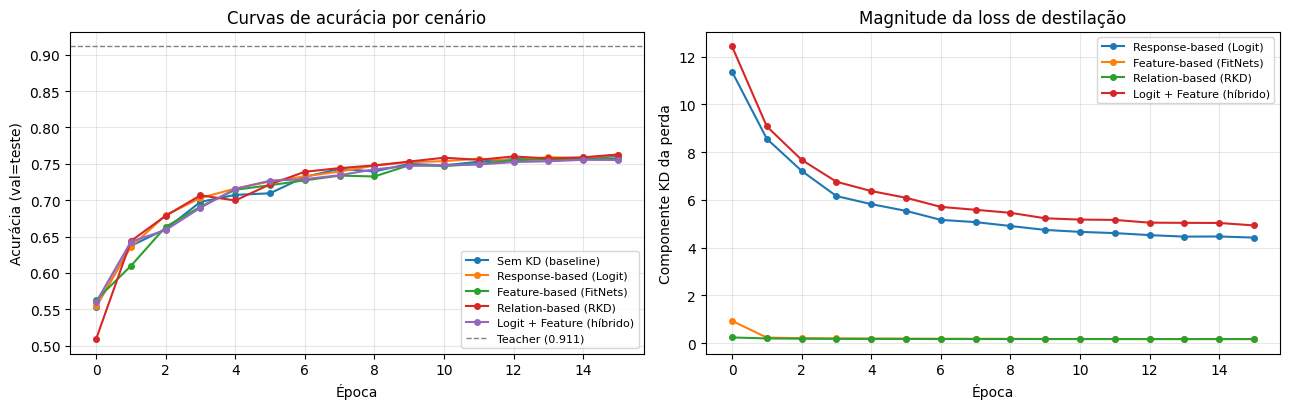

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for mode in MODE_NAMES:
    axes[0].plot(histories[mode]['val_acc'], marker='o', ms=4, label=MODE_NAMES[mode])
axes[0].axhline(acc_t, ls='--', color='gray', lw=1, label=f'Teacher ({acc_t:.3f})')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Acurácia (val=teste)')
axes[0].set_title('Curvas de acurácia por cenário'); axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)

for mode in ['logit', 'feature', 'relation', 'hybrid']:
    axes[1].plot(histories[mode]['train_kd'], marker='o', ms=4, label=MODE_NAMES[mode])
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Componente KD da perda')
axes[1].set_title('Magnitude da loss de destilação'); axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)

plt.tight_layout()
fig.savefig(os.path.join(ART_DIR, 'training_curves.png'), dpi=130)
plt.show()


### 5.3 Acurácia × parâmetros e ganho vs baseline

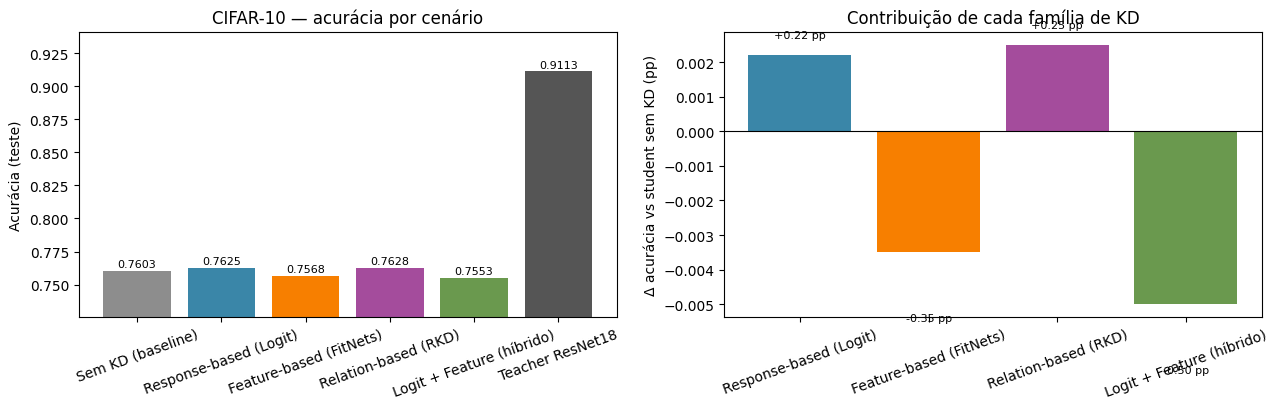

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

modes = list(MODE_NAMES) + ['teacher']
labels = [MODE_NAMES[m] for m in MODE_NAMES] + ['Teacher ResNet18']
accs = [results[m]['acc'] for m in MODE_NAMES] + [acc_t]
colors = ['#8d8d8d', '#3a86a8', '#f77f00', '#a44c9c', '#6a994e', '#555555']

ax = axes[0]
bars = ax.bar(labels, accs, color=colors)
for b, v in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, v + 0.003, f'{v:.4f}', ha='center', fontsize=8)
ax.set_ylabel('Acurácia (teste)'); ax.set_ylim(min(accs) - 0.03, max(accs) + 0.03)
ax.set_title('CIFAR-10 — acurácia por cenário')
ax.tick_params(axis='x', rotation=20)

ax = axes[1]
deltas = [results[m]['acc'] - base_acc for m in MODE_NAMES if m != 'baseline']
dlabels = [MODE_NAMES[m] for m in MODE_NAMES if m != 'baseline']
dcolors = ['#3a86a8', '#f77f00', '#a44c9c', '#6a994e']
bars = ax.bar(dlabels, deltas, color=dcolors)
for b, v in zip(bars, deltas):
    ax.text(b.get_x() + b.get_width()/2, v + (0.0005 if v >= 0 else -0.002),
            f'{v*100:+.2f} pp', ha='center', fontsize=8)
ax.axhline(0, color='k', lw=.8)
ax.set_ylabel('Δ acurácia vs student sem KD (pp)')
ax.set_title('Contribuição de cada família de KD')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
fig.savefig(os.path.join(ART_DIR, 'kd_contribution.png'), dpi=130)
plt.show()


## 6. Conclusões

*(Preenchidas após a execução — ver resultado reais acima e artefatos/README.)*

In [14]:
# Artefatos finais + MLflow (nomes de métricas válidos: sem parênteses/acentos)
summary = {'teacher': float(acc_t)}
summary.update({f'{m}_acc': float(results[m]['acc']) for m in results})
with mlflow.start_run(run_name='Final_Artifacts'):
    mlflow.log_artifact(os.path.join(ART_DIR, 'results.csv'))
    mlflow.log_artifact(os.path.join(ART_DIR, 'training_curves.png'))
    mlflow.log_artifact(os.path.join(ART_DIR, 'kd_contribution.png'))
    mlflow.log_metrics(summary)
    mlflow.log_metrics({'final_baseline_acc': float(results['baseline']['acc']),
                        'final_logit_acc': float(results['logit']['acc']),
                        'final_feature_acc': float(results['feature']['acc']),
                        'final_relation_acc': float(results['relation']['acc']),
                        'final_hybrid_acc': float(results['hybrid']['acc'])})
print('Artefatos salvos em:', os.path.abspath(ART_DIR))


Artefatos salvos em: D:\mlops-experiments\experiments\artifacts\kd_cifar10_20260811_153554_02959521
